# NB1 — Cleaning, Hazard Structuring, and Focused EDA


This is an English, curated retrospective of the first bootcamp project. It follows the original presentation and retains the experiments needed to understand the selected model. It does not include the later Claude Code/GitHub upgrade.

**Two kinds of evidence:** snapshot statistics are computed from the supplied CSV; historical model metrics are transcribed from the original notebooks' stored outputs and explicitly labeled. The models have not been retrained for this edition. Set the relevant run flag to opt into an adapted historical rerun; scores may differ because the original `df_keyword.csv`, environment, and all intermediate states are unavailable. The supplied `CleanedDataset.csv` is used as a documented substitute, not asserted to be byte-identical to that intermediate file.

Cells carry original filenames and zero-based cell references in metadata. No API call or model download runs by default. The original evaluation limitations are noted without silently replacing the first project with an improved pipeline.


## Reading map
Presentation pages 3–6: inspect the records → clean structural issues → create a hazard taxonomy from subject text → normalize hazard names → explore the resulting fields.

The final snapshot is loaded first so this notebook remains readable without regenerating API-derived labels. The raw-data section below separately reconstructs selected cleaning operations.


In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

# Place the supplied CSV files in data/, or set RASFF_DATA_DIR.
DATA_DIR = Path(os.environ.get("RASFF_DATA_DIR", "data"))
clean_path = DATA_DIR / "CleanedDataset.csv"
if not clean_path.exists():
    raise FileNotFoundError("Place the original CleanedDataset.csv in data/ or set RASFF_DATA_DIR.")
df = pd.read_csv(clean_path).reset_index(drop=True)
RUN_EXPERIMENTS = False
RUN_LLM_SAMPLE = False
SAVE_ARTIFACTS = False
print(f"Provided clean snapshot: {df.shape[0]:,} rows x {df.shape[1]} columns")


Provided clean snapshot: 27,397 rows x 23 columns


## 1. Establish the data actually used in the first project
The presentation reported the 27,398 rows read by pandas. Removing one row with a missing product category left 27,397 records. The supplied cleaned file has 23 columns, including engineered fields. This is notification data; counts do not estimate the risk of all marketed food.


In [2]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
snapshot = pd.Series({
    "Rows": len(df), "Columns": len(df.columns),
    "First date": df["date"].min(), "Last date": df["date"].max(),
    "Missing hazards": int(df["hazards"].isna().sum()),
    "Missing hazards (%)": round(df["hazards"].isna().mean()*100, 2),
    "Distinct nonmissing hazard strings": df["hazards"].nunique(),
    "Distinct nonmissing simplified hazards": df["simplified_hazard"].nunique(),
})
display(snapshot.to_frame("Verified snapshot value"))


,Verified snapshot value
Rows,27397
Columns,23
First date,2020-01-02 09:24:48
Last date,2025-10-31 16:30:35
Missing hazards,7156
Missing hazards (%),26.12
Distinct nonmissing hazard strings,2795
Distinct nonmissing simplified hazards,1641


## 2. Reconstruct the selected raw-data cleaning steps
The original loader used `on_bad_lines="skip"`. This section makes that operation visible and counts CSV records independently. It is not a malformed-row recovery algorithm.

The original notebook manually repaired a shifted row whose `risk_decision` was `Poland`, and separately repaired the date of reference 2021.2621. The correction values below come from that notebook; their official external source was not supplied. This streamlined version applies the date correction in place rather than reintroducing the original temporary `NaT` state.


In [3]:
import csv
from collections import Counter
raw_path = DATA_DIR / "RASFF_originaldataset.csv"
if raw_path.exists():
    with raw_path.open(newline="", encoding="utf-8-sig") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        field_counts = Counter(len(row) for row in reader)
    raw = pd.read_csv(raw_path, on_bad_lines="skip")
    base = raw.dropna(subset=["category"]).copy()
    print("CSV field-count distribution:", dict(sorted(field_counts.items())))
    print("Rows read by pandas:", len(raw))
    print("Rows after category check:", len(base))
    shifted = base["risk_decision"].eq("Poland")
    correction_columns = ["date", "notifying_country", "classification", "risk_decision",
                          "distribution", "forAttention", "forFollowUp", "operator", "origin", "hazards"]
    base.loc[shifted, correction_columns] = [
        "25-05-2021", "poland", "information notification for attention", "serious",
        "poland", "hungary", "NaN", "hungary, poland", "hungary, poland", "Salmonella Enteritidis"]
    base["date"] = pd.to_datetime(base["date"], dayfirst=True, errors="coerce", format="mixed")
    base.loc[base["reference"].eq(2021.2621), "date"] = pd.Timestamp("2021-05-25")
    base["year"] = base["date"].dt.year
    base["month"] = base["date"].dt.month
    print("Shifted rows repaired:", int(shifted.sum()))
    print("Remaining unparsed dates:", int(base["date"].isna().sum()))
else:
    print("Optional raw CSV unavailable; continue with the supplied clean snapshot.")


CSV field-count distribution: {13: 1, 14: 27397, 15: 9, 16: 4, 17: 1}
Rows read by pandas: 27398
Rows after category check: 27397
Shifted rows repaired: 1
Remaining unparsed dates: 0


## 3. Why hazard structuring mattered
`hazards` was often empty, while `subject` could still describe the problem. Repeated spellings, combined agents, and regulatory wording also made raw strings difficult to use directly. Missing hazards were not all deleted. Two complementary features were developed:

| Feature | Input | Meaning |
|---|---|---|
| `Hazard_Type` | `subject` | Broad, project-generated hazard category |
| `simplified_hazard` | `hazards` | Normalized agent/chemical string, with unmatched text retained |

Keyword extraction from `subject` was a separate exploration and was not an additional input of the selected final model.


In [4]:
display(df[["hazards", "simplified_hazard", "Hazard_Type"]].isna().sum().to_frame("Missing values"))
display(df["Hazard_Type"].value_counts().rename_axis("Project-generated category").to_frame("Notifications"))


,Missing values
hazards,7156
simplified_hazard,7156
Hazard_Type,0


,Notifications
Project-generated category,
Chemical/Contaminants,8741
Microbiological,6758
Mycotoxins,3210
Others,2968
Novel/Unauthorised Ingredient,2842
Allergen,1238
Physical Contaminants,1024
Migration from Packaging,557
Fraud/Adulteration,59


## 4. From eight categories to a nine-category LLM taxonomy
The initial GPT-4o-mini experiment used eight categories. Reviewing `Others` and `Fraud/Adulteration` led to the addition of `Novel/Unauthorised Ingredient`. An intermediate reclassification reduced stored `Others` counts from 4,526 to 2,454 and introduced 1,115 novel-food labels. Those were intermediate counts, not the final snapshot distribution and not measured accuracy gains.

The final prompt prioritized the technical hazard over regulatory status and asked the model to use English when multilingual descriptions were present. The resulting nine-category counts match the supplied cleaned CSV. These are project-created labels, not an official RASFF taxonomy. No manually labeled accuracy benchmark was supplied.

The optional code below retains the original batch function, including its response parsing and fallback behavior. It only classifies five sample subjects if explicitly enabled. It never overwrites the snapshot labels.


In [5]:
if RUN_LLM_SAMPLE:
    from openai import OpenAI
    from tqdm import tqdm
    import time

    # 1. Initialize the OpenAI Client
    # Ensure your OPENAI_API_KEY is set as an environment variable or passed here
    client = OpenAI()

    # 2. Define the Target Categories (for validation and reference)
    CATEGORIES = [
        "Microbiological", 
        "Chemical/Contaminants", 
        "Mycotoxins", 
        "Allergen", 
        "Physical Contaminants", 
        "Migration from Packaging", 
        "Fraud/Adulteration", 
        "Novel/Unauthorised Ingredient", 
        "Others"
    ]

    # 3. Define the Batch Classification Function
    def classify_subject_batch(subject_list, model="gpt-4o-mini", max_retries=3):
        """
        Sends a batch of subjects to the OpenAI API for classification.
        Implements a simple retry mechanism for robustness.
        """
        # Format numbered list for batch
        formatted_subjects = "\n".join([f"{i+1}. {s}" for i, s in enumerate(subject_list)])

        # Insert the formatted subjects into the strong prompt
        prompt = f"""
        You are a specialized food safety expert tasked with classifying RASFF alert subject lines. Your goal is to identify the single, most critical **TECHNICAL HAZARD TYPE** present in the food or feed product.

        **STRICT RULES FOR CLASSIFICATION:**
        1.  **Technical Hazard Priority:** Always classify by the **type of contaminant/agent** (e.g., bacteria, metal, pesticide) over the **regulatory status** (e.g., 'unauthorized', 'absence of certificate').
        2.  **Language Handling:** If the subject line contains multiple languages (separated by // or ///), use the English text for classification.
        3.  **Output Format:** Return the category as a numbered list, with ONLY the category name on each line. Do not include quotes, numbering, or any other text.
        4.  **Novel/Unauthorised:** Use this category ONLY for substances that are unauthorized or not approved for the specific food use.
        5.  **OTHERS:** Use this ONLY when the subject describes a purely administrative or procedural issue with no mention of a physical, chemical, or biological contaminant.

        **TECHNICAL HAZARD CATEGORIES & DEFINITIONS:**

        1.  **Microbiological:** Harmful living organisms like bacteria, viruses, parasites, or fungi. (Focus on names like *Salmonella*, *Listeria*, *E. coli*).
        2.  **Chemical/Contaminants:** Specific non-mycotoxin chemicals, heavy metals, industrial contaminants, pesticide residues, or unauthorized additives. (Focus on substances like *titanium dioxide*, *lead*, *oxamyl*, *dioxins*).
        3.  **Mycotoxins:** Toxins produced by molds/fungi, primarily found in grains, nuts, and dried fruit. (Focus on names like *Aflatoxin*, *Ochratoxin*).
        4.  **Allergen:** Undeclared ingredients that cause allergic reactions. (Focus on *undeclared*, *milk*, *soy*, *peanut*, *CASEINE*).
        5.  **Physical Contaminants:** Foreign objects causing physical harm or injury. (Focus on *glass*, *metal*, *plastic*, *stone*, *bone*).
        6.  **Migration from Packaging:** Chemical substances transferring from the packaging into the food/feed. (Focus on *migration*, *PAA*, *Bisphenol*).
        7.  **Fraud/Adulteration:** Intentional deception regarding a product's composition or identity, typically for economic gain. (Focus on *adulterated*, *mismatch*, *mislabelled origin*).
        8.  **Novel/Unauthorised Ingredient:** Ingredients that have not been authorized under novel food regulations. (Focus on *novel food ingredient*, *unauthorized botanicals*).
        9.  **Others:** No technical hazard is specified (e.g., only 'Absence of official certificates').

        **CLASSIFY THE FOLLOWING SUBJECT LINES:**

        Now classify the following subjects:

        Subject:
        "{formatted_subjects}"

        Return the output as a numbered list with ONLY the category name per line, e.g.:
        1. Microbiological
        2. Chemical/Contaminants
        3. Others
        """

        # Simple retry logic
        for attempt in range(max_retries):
            try:
                response = client.chat.completions.create(
                    model=model,
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0, # Use 0 for deterministic classification tasks
                )

                # Process the response: extract and validate categories
                raw_output = response.choices[0].message.content.strip().split("\n")
                cleaned_output = []

                for line in raw_output:
                    # Remove the number and period (e.g., "1. Microbiological" -> "Microbiological")
                    if ". " in line:
                        cat = line.split(". ", 1)[1].strip()
                    else:
                        cat = line.strip()

                    # Validation: Fallback to "Others" if the LLM hallucinated a category name
                    if cat not in CATEGORIES:
                        cat = "Others"

                    # Stop when the number of classified items matches the input
                    if len(cleaned_output) < len(subject_list):
                        cleaned_output.append(cat)

                # Pad with "Others" if the LLM output was too short (rare but possible)
                while len(cleaned_output) < len(subject_list):
                     cleaned_output.append("Others")

                return cleaned_output

            except Exception as e:
                print(f"API Error on attempt {attempt + 1}/{max_retries}: {e}")
                if attempt < max_retries - 1:
                    # Wait for 2^attempt seconds before retrying (Exponential Backoff)
                    time.sleep(2 ** attempt)
                else:
                    print(f"Failed to classify batch after {max_retries} attempts. Returning 'Others' for batch.")
                    return ["Others"] * len(subject_list)
        return ["Others"] * len(subject_list) # Should not be reached

    # 4. Main Execution Block for DataFrame
    def classify_full_dataframe(df, subject_column='subject', batch_size=50):
        """Classifies the entire DataFrame in batches."""

        # ⚠️ IMPORTANT: Handle potential missing values by converting to string
        subjects = df[subject_column].fillna("N/A - Missing Subject").astype(str).tolist()

        results = []

        # Use tqdm for a professional progress bar
        for i in tqdm(range(0, len(subjects), batch_size), desc="Classifying RASFF Subjects"):
            batch = subjects[i:i + batch_size]
            batch_results = classify_subject_batch(batch)
            results.extend(batch_results)

            # Add a short delay to respect rate limits
            time.sleep(0.1) 

        df['Hazard_Type'] = results
        return df



    llm_sample_labels = classify_subject_batch(df["subject"].head(5).tolist())
    print(llm_sample_labels)
else:
    print("Optional historical experiment skipped.")


Optional historical experiment skipped.


## 5. Preserve the useful hazard-name normalization
The original code lowercased the strings, removed punctuation noise, consolidated frequent variants for inspection, and used an ordered list of 20 frequent hazards for substring matching. **Unmatched strings were retained.** Consequently, `simplified_hazard` did not become a 20-class field.

The code below reconstructs this transformation into a separate column for inspection; the supplied final `simplified_hazard` remains the modeling input. Empty strings can be serialized as missing values when the original CSV is reread.


In [6]:
# Create a dictionary to map specific/noisy terms to the desired standardized term (all lowercase)
CONSOLIDATION_MAP = {
    # --- Aflatoxin Consolidation ---
    "aflatoxin b1  aflatoxin total": "aflatoxin",
    "aflatoxin b1": "aflatoxin",
    "aflatoxins": "aflatoxin",
    "aflatoxin total": "aflatoxin",
    "aflatoxin m1": "aflatoxin",
    "aflatoxin b1 aflatoxins b1" : "aflatoxin",
    "aflatoxins b1" : "aflatoxin",
    "aflatoxin b1  aflatoxins b1" : "aflatoxin",

    # --- Salmonella Consolidation ---
    "salmonella spp.": "salmonella",
    "salmonella enteritidis": "salmonella",
    "salmonella infantis": "salmonella",
    "salmonella spp": "salmonella",
    "salmonella": "salmonella",
    "salmonella typhimurium" : "salmonella",
    "salmonella  enteritidis" : "salmonella",
    "salmonella newport" : "salmonella",


    # --- Pesticides/Chemicals Consolidation ---
    "chlorpyrifos unauthorised substance": "chlorpyrifos",
    "chlorpyrifos-methyl": "chlorpyrifos",
    "chlorpyrifos-methyl unauthorised substance" : "chlorpyrifos",
    "chlorpyriphos-ethyl" : "chlorpyrifos",
    "chlorpyrifos  unauthorised substance" : "chlorpyrifos",
    "chlorpyrifos-methyl  unauthorised substance" : "chlorpyrifos",

    # --- E. coli Consolidation (if needed) ---
    "escherichia coli shigatoxin-producing": "escherichia coli",
}
# The list of the top 20 standardized keywords (must be lowercase)
TOP_20_HAZARDS = [
    'salmonella', 'aflatoxin', 'chlorpyrifos', 'ethylene oxide', 
    'listeria monocytogenes', 'ochratoxin a', 'mercury', 'cadmium', 
    'escherichia coli', 'pyrrolizidine alkaloids', 'norovirus', 
    'primary aromatic amines migration', 'acetamiprid', 'histamine', 
    'pesticide residues', 'mineral oil', 'chlorate', 
    'tetrahydrocanabinol thc', 'sulphite', 'formetanate'
]


In [7]:
import re
hazard_cleaned = df["hazards"].fillna("").astype(str).str.lower().str.strip()
hazard_cleaned = hazard_cleaned.map(lambda text: re.sub(r"[^\w\s\.-]", "", text))
counts = hazard_cleaned[hazard_cleaned.ne("")].value_counts().rename_axis("keyword").reset_index(name="count")
counts["mapped_keyword"] = counts["keyword"].map(lambda text: CONSOLIDATION_MAP.get(text, text))
display(counts.groupby("mapped_keyword")["count"].sum().nlargest(10).to_frame())

def assign_single_hazard_refined(text, hazard_list):
    if not isinstance(text, str) or not text:
        return ""
    compact = text.replace(" ", "").replace(".", "")
    for hazard in hazard_list:
        if hazard.replace(" ", "").replace(".", "") in compact:
            return hazard
    return text

hazard_text = df["hazards"].fillna("").astype(str).str.lower().map(
    lambda text: re.sub(r"[^\w\s\.-]", " ", text))
reconstructed = hazard_text.map(lambda text: assign_single_hazard_refined(text, TOP_20_HAZARDS))
display(pd.DataFrame({"Provided simplified_hazard": df["simplified_hazard"].fillna(""),
                      "Reconstructed for inspection": reconstructed}).head(10))
print("Reconstruction matches provided field:", reconstructed.eq(df["simplified_hazard"].fillna("")).mean())


Reconstruction matches provided field: 1.0


,count
mapped_keyword,
salmonella,2949
aflatoxin,2283
chlorpyrifos,1143
ethylene oxide,884
listeria monocytogenes,736
ochratoxin a,433
mercury,338
cadmium,311
escherichia coli,282


,Provided simplified_hazard,Reconstructed for inspection
0,,
1,,
2,,
3,listeria monocytogenes,listeria monocytogenes
4,not in catalogue,not in catalogue
5,,
6,salmonella,salmonella
7,dimethomorph,dimethomorph
8,,
9,,


## 6. Focused EDA for the modeling question
Retain risk-label counts and relationships with product categories and hazard types. Repeated plots, unrestricted high-cardinality association matrices, and top-subset pie charts were removed. A notification share within this dataset is not the risk rate of food from a country or category.


In [8]:
display(df["risk_decision"].value_counts().rename_axis("Recorded risk label").to_frame("Notifications"))
hazard_risk = pd.crosstab(df["Hazard_Type"], df["risk_decision"])
display(hazard_risk)
top_categories = df["category"].value_counts().head(10).index
category_risk = pd.crosstab(df.loc[df["category"].isin(top_categories), "category"],
                           df.loc[df["category"].isin(top_categories), "risk_decision"])
display(category_risk)


,Notifications
Recorded risk label,
serious,14756
not serious,4134
undecided,3029
potential risk,2689
potentially serious,2372
no risk,417


risk_decision,no risk,not serious,potential risk,potentially serious,serious,undecided
Hazard_Type,,,,,,
Allergen,2,42,38,68,1069,19
Chemical/Contaminants,203,946,728,1066,4557,1241
Fraud/Adulteration,3,14,9,8,16,9
Microbiological,21,1387,408,446,4197,299
Migration from Packaging,2,86,70,76,238,85
Mycotoxins,10,109,85,175,2769,62
Novel/Unauthorised Ingredient,30,428,718,239,701,726
Others,141,1038,527,168,587,507
Physical Contaminants,5,84,106,126,622,81


risk_decision,no risk,not serious,potential risk,potentially serious,serious,undecided
category,,,,,,
cereals and bakery products,50,270,195,200,855,209
"dietetic foods, food supplements and fortified foods",31,112,469,178,725,432
feed materials,16,541,174,61,168,112
fish and fish products,11,315,103,73,846,128
food contact materials,9,384,140,93,349,139
fruits and vegetables,147,413,360,506,2632,876
herbs and spices,31,105,96,216,1182,133
meat and meat products (other than poultry),4,144,82,109,699,117
"nuts, nut products and seeds",18,232,123,148,2642,128


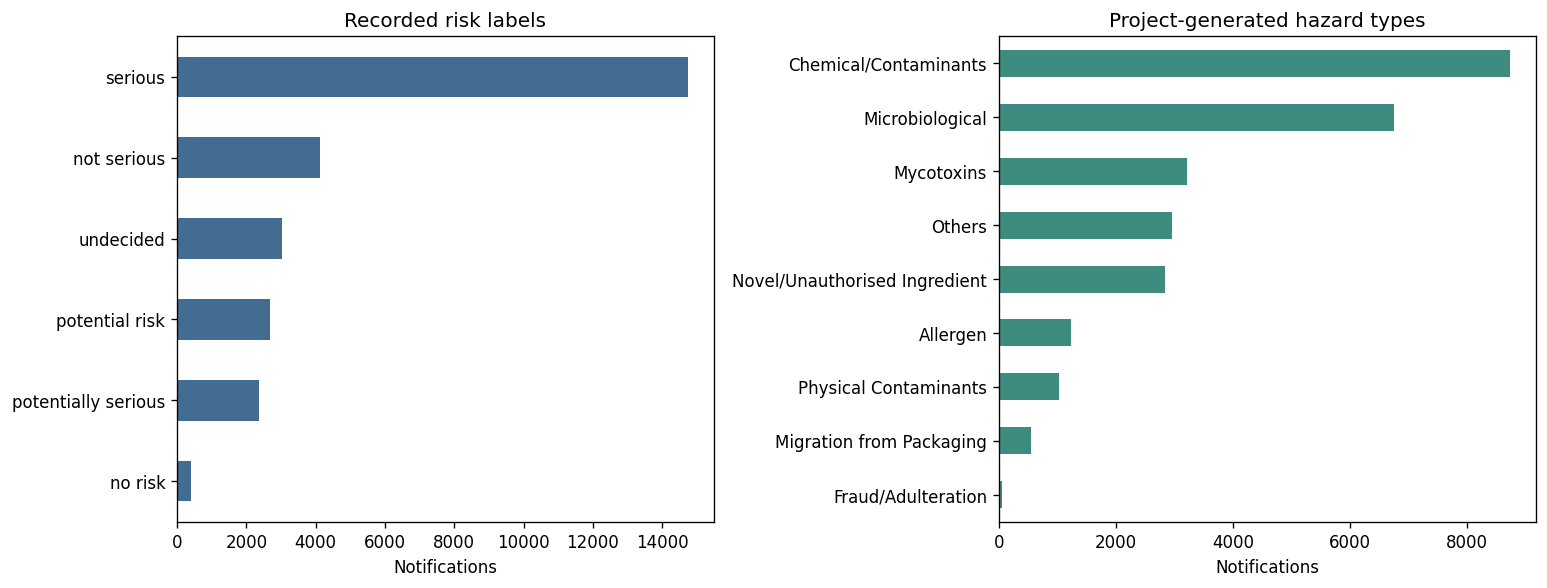

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df["risk_decision"].value_counts().sort_values().plot.barh(ax=axes[0], color="#426d91")
df["Hazard_Type"].value_counts().sort_values().plot.barh(ax=axes[1], color="#3e8b80")
axes[0].set(title="Recorded risk labels", xlabel="Notifications", ylabel="")
axes[1].set(title="Project-generated hazard types", xlabel="Notifications", ylabel="")
fig.tight_layout()
plt.show()


## Handoff to NB2
The next question is how to turn these fields into numerical features and define a learnable target. Keep the provided clean snapshot as the common input. No LLM rerun is required to read the rest of this retrospective.
